In [8]:
import os

import pandas as pd
from pathlib import Path

os.chdir(r"/home/enzo-maldinni/Documentos/SIGAMA-data-analysis")
print(os.getcwd())

from src.utils.parsing import parse_args, load_config

import sys
sys.argv = [sys.argv[0]]

args = parse_args()
cfg = load_config(args)

paths = cfg["paths"]

clusters_path = f'{cfg["paths"]["processed"]}'

print(clusters_path)

open_tickets_file = Path(clusters_path) / "clusters_open_tickets_defined_distinguished_trends.csv"

print(open_tickets_file)


/home/enzo-maldinni/Documentos/SIGAMA-data-analysis
data/processed
data/processed/clusters_open_tickets_defined_distinguished_trends.csv


In [9]:
import pandas as pd
import re
import unicodedata

def normalize_text(text):
    if pd.isna(text):
        return text
    
    # remover acentos
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8")
    
    # lowercase
    text = text.lower()
    
    # remover hífen no início
    text = re.sub(r"^-+", "", text)
    
    # remover pontuação
    text = re.sub(r"[^\w\s]", "", text)
    
    # remover espaços extras
    text = re.sub(r"\s+", " ", text)
    
    text = text.strip()
    
    # capitalizar
    text = text.capitalize()
    
    return text

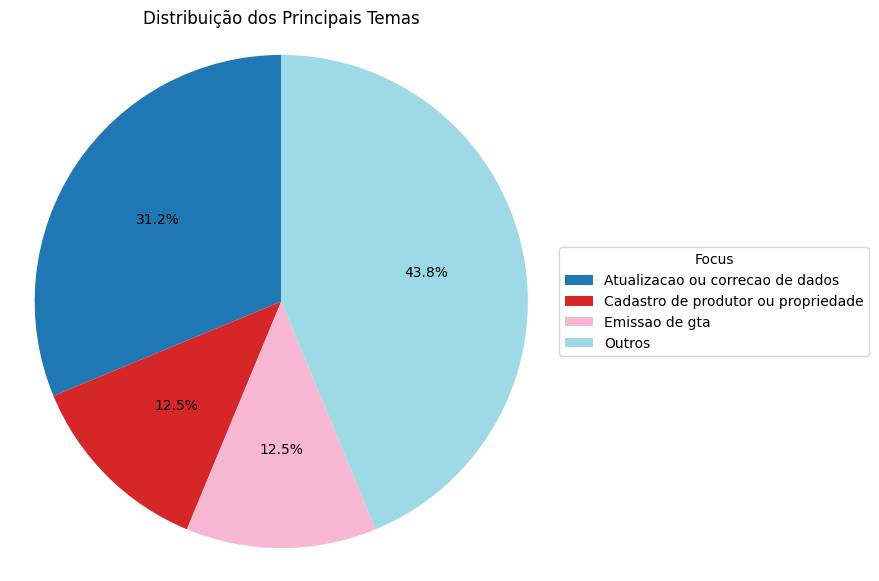

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# carregar dataset
df = pd.read_csv(open_tickets_file)

# quebrar múltiplos temas
focus_series = (
    df["Focus"].apply(normalize_text)
    .dropna()
    .str.split("|")
    .explode()
    .str.strip()
)
# contar frequência
focus_counts = focus_series.value_counts()

# pegar top 5
top5 = focus_counts.head(3)

# somar restante
others = focus_counts.iloc[3:].sum()

# combinar
plot_data = pd.concat([top5, pd.Series({"Outros": others})])

# plot
plt.figure(figsize=(7,7))

n = len(plot_data)

colors = plt.cm.tab20(np.linspace(0, 1, n))

wedges, texts, autotexts = plt.pie(
    plot_data.values,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.legend(
    wedges,
    plot_data.index,
    title="Focus",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.axis('equal')
plt.title("Distribuição dos Principais Temas")

plt.show()



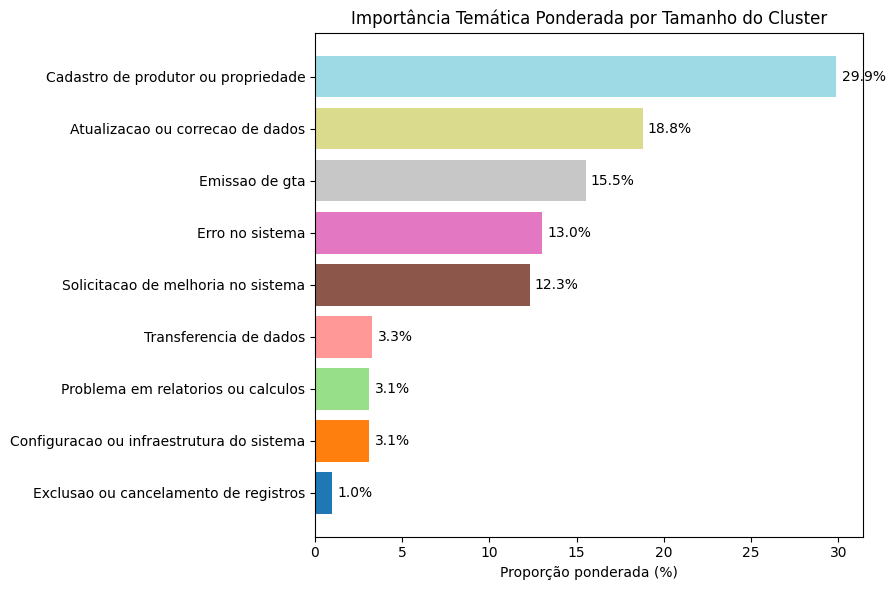

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(open_tickets_file)

focus_map = {
    "Alteracao ou correcao de dados": "Atualizacao ou correcao de dados"
}

# separar múltiplos temas
focus_expanded = (
    df[["Focus", "Size"]]
    .dropna()
    .assign(Focus=lambda x: x["Focus"].str.split("|"))
    .explode("Focus")
)

# limpar espaços
focus_expanded["Focus"] = focus_expanded["Focus"].str.strip().apply(normalize_text).replace(focus_map)

# somar Size por tema
focus_weighted = (
    focus_expanded
    .groupby("Focus")["Size"]
    .sum()
    .sort_values(ascending=False)
)

# pegar top 10
plot_data = focus_weighted.head(10)

# converter para proporção
plot_data_pct = plot_data / plot_data.sum() * 100

# ordenar para visualização
plot_data_pct = plot_data_pct.sort_values()

# cores
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_data_pct)))

# gráfico
plt.figure(figsize=(9,6))

bars = plt.barh(plot_data_pct.index, plot_data_pct.values, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             va='center')

plt.xlabel("Proporção ponderada (%)")
plt.title("Importância Temática Ponderada por Tamanho do Cluster")

plt.tight_layout()
plt.show()



datetime64[us, UTC]


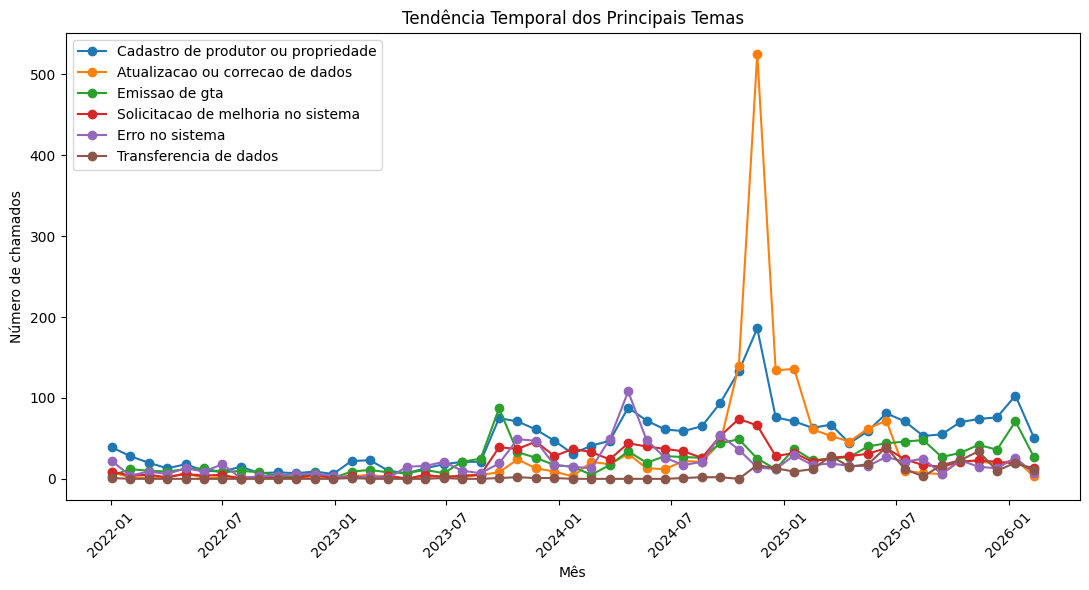

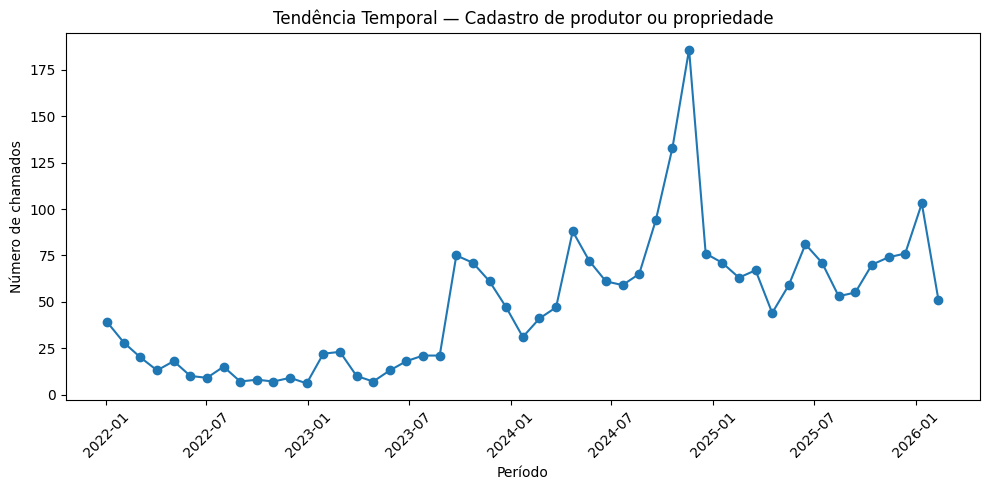

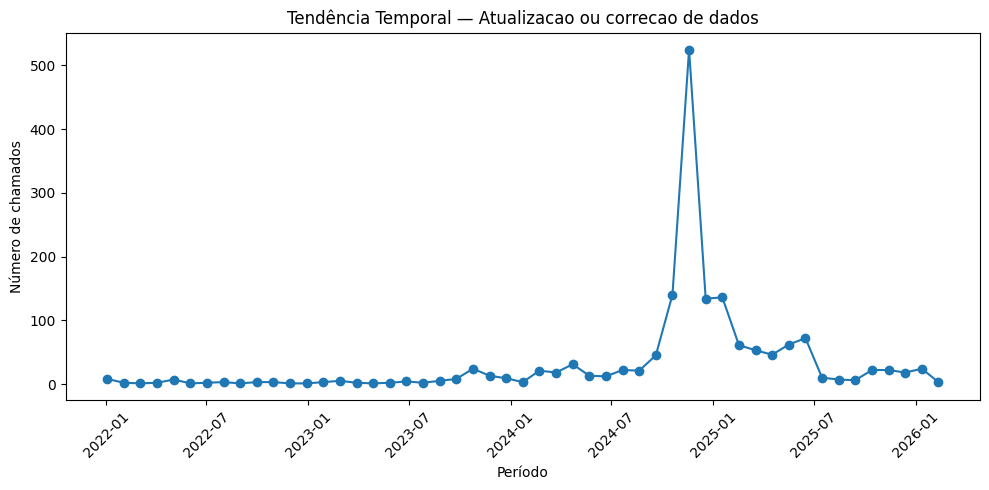

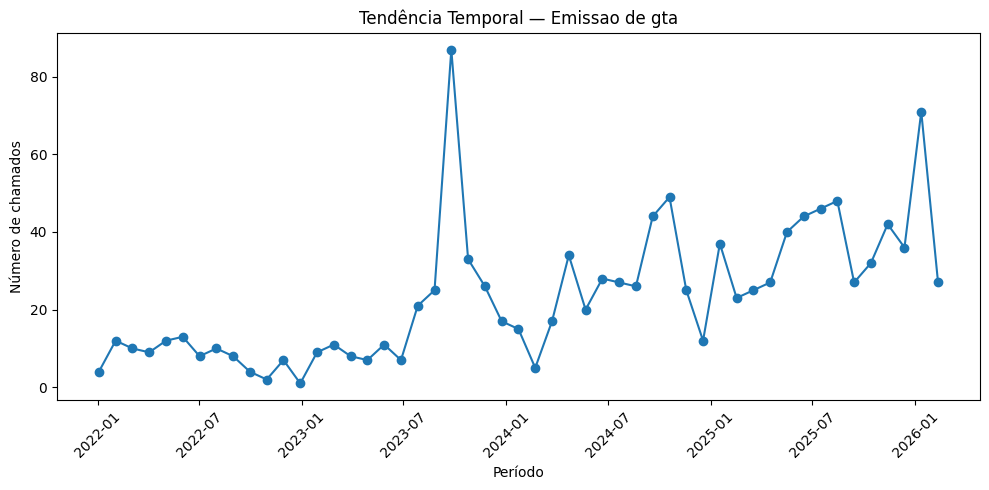

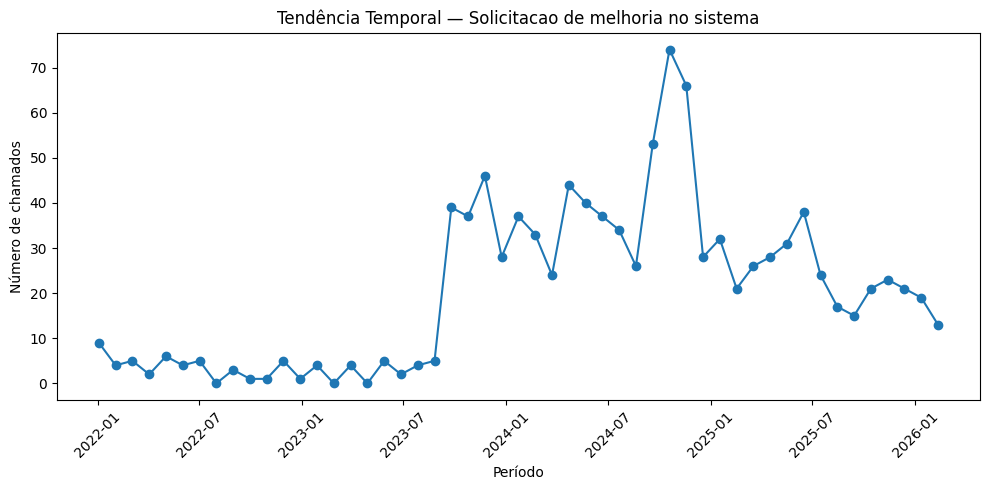

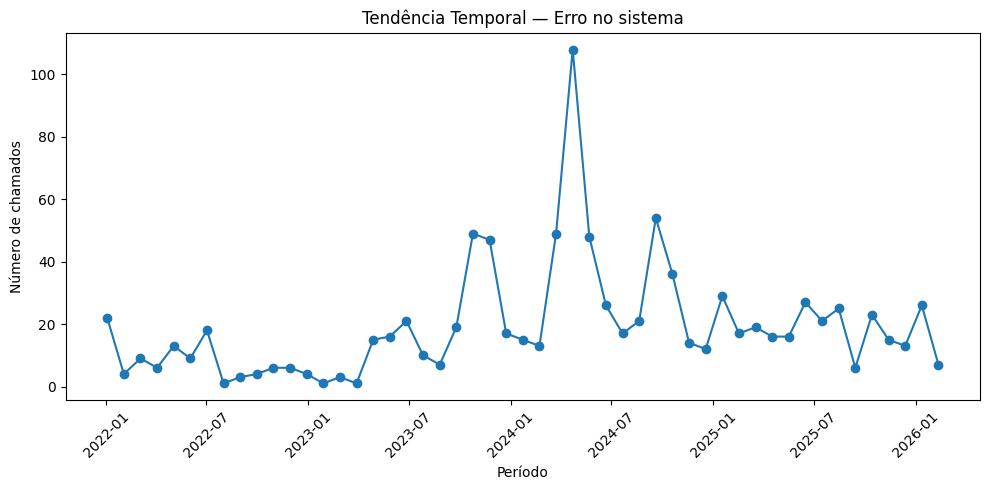

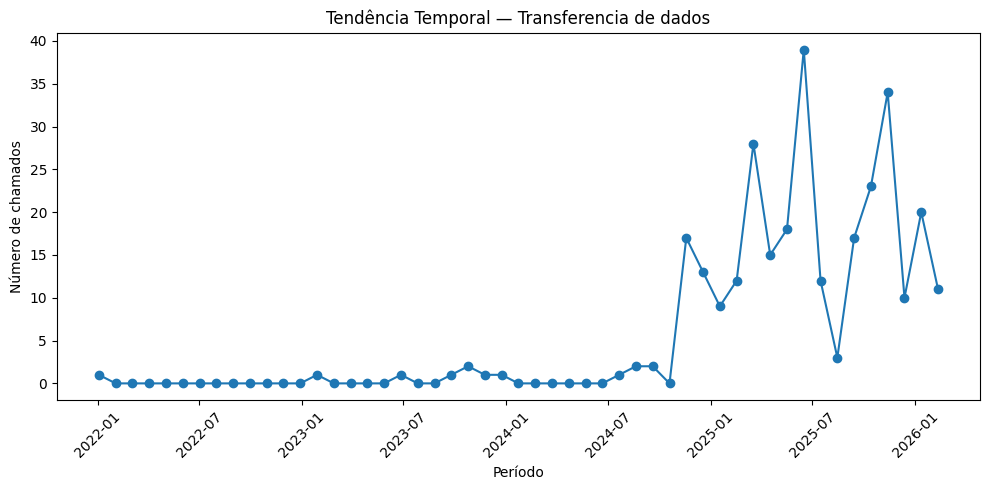

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# carregar datasets
articles_file = Path(clusters_path) / "chamado_abrir_202603041306_limpo_clustered.csv"

news_df = pd.read_csv(articles_file)
clusters_df = pd.read_csv(open_tickets_file)

focus_map = {
    "Alteracao ou correcao de dados": "Atualizacao ou correcao de dados"
}

# converter datas
news_df["dt_chamado"] = pd.to_datetime(
    news_df["dt_chamado"],
    errors="coerce",
    utc=True
)

# remover datas inválidas
news_df = news_df.dropna(subset=["dt_chamado"])

print(news_df["dt_chamado"].dtype)

# remover timezone
news_df["dt_chamado"] = news_df["dt_chamado"].dt.tz_localize(None)

# criar coluna mês
news_df["month"] = news_df["dt_chamado"].dt.to_period("M")

# juntar artigos com clusters
# filtrar datas
news_df = news_df[news_df["dt_chamado"] >= "2022-01-01"]

news_df["period"] = news_df["dt_chamado"]

merged = news_df.merge(
    clusters_df[["Cluster ID", "Focus"]],
    on="Cluster ID",
    how="left"
)

focus_expanded = (
    merged[["period", "Focus"]]
    .dropna()
    .assign(Focus=lambda x: x["Focus"].str.split("|"))
    .explode("Focus")
)

focus_expanded["Focus"] = focus_expanded["Focus"].str.strip().apply(normalize_text).replace(focus_map)

trend = (
    focus_expanded
    .groupby([pd.Grouper(key="period", freq="30D"), "Focus"])
    .size()
    .reset_index(name="count")
)

trend_pivot = trend.pivot(index="period", columns="Focus", values="count").fillna(0)

# ordenar cronologicamente
trend_pivot = trend_pivot.sort_index()

# principais temas
top_topics = focus_expanded["Focus"].value_counts().head(6).index
trend_top = trend_pivot[top_topics]

# plot
plt.figure(figsize=(11,6))

for col in trend_top.columns:
    plt.plot(trend_top.index, trend_top[col], marker="o", label=col)

plt.xticks(rotation=45)
plt.ylabel("Número de chamados")
plt.xlabel("Mês")
plt.title("Tendência Temporal dos Principais Temas")
plt.legend()

plt.tight_layout()
plt.show()

for topic in top_topics:
    
    plt.figure(figsize=(10,5))
    
    plt.plot(
        trend_top.index,
        trend_top[topic],
        marker="o"
    )
    
    plt.xticks(rotation=45)
    plt.ylabel("Número de chamados")
    plt.xlabel("Período")
    plt.title(f"Tendência Temporal — {topic}")
    
    plt.tight_layout()
    plt.show()

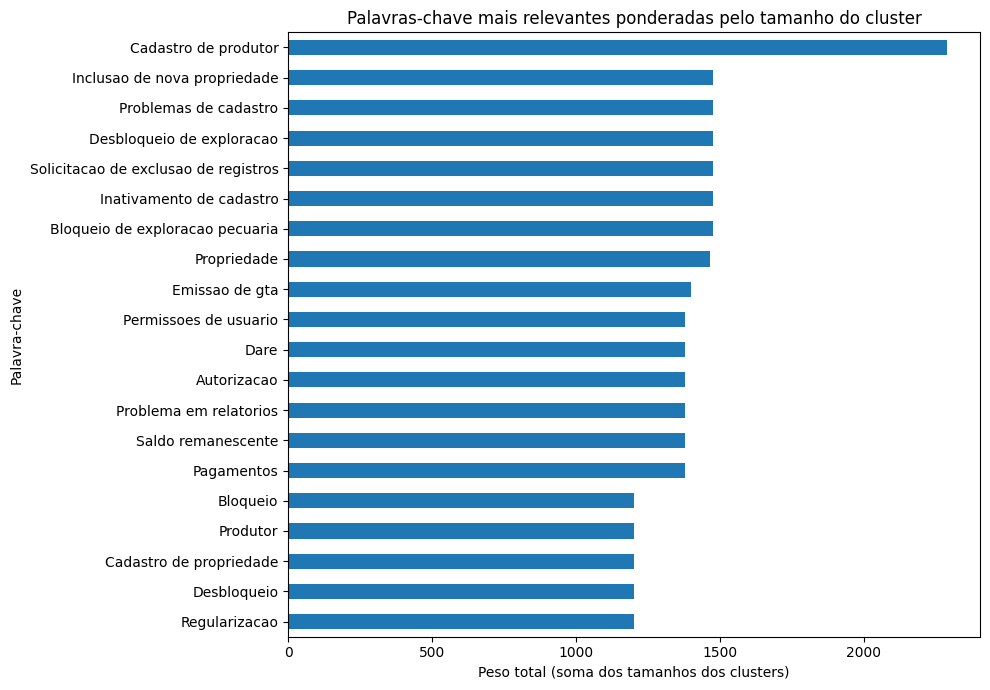

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

keywords_expanded = (
    clusters_df[["Keywords", "Size"]]
    .dropna()
    .assign(Keywords=lambda x: x["Keywords"].str.split(";"))
    .explode("Keywords")
)

keywords_expanded["Keywords"] = keywords_expanded["Keywords"].str.strip().apply(normalize_text)

keyword_weight = (
    keywords_expanded
    .groupby("Keywords")["Size"]
    .sum()
    .sort_values(ascending=False)
)

top_keywords = keyword_weight.head(20)

plt.figure(figsize=(10,7))

top_keywords.sort_values().plot(kind="barh")

plt.xlabel("Peso total (soma dos tamanhos dos clusters)")
plt.ylabel("Palavra-chave")
plt.title("Palavras-chave mais relevantes ponderadas pelo tamanho do cluster")

plt.tight_layout()
plt.show()

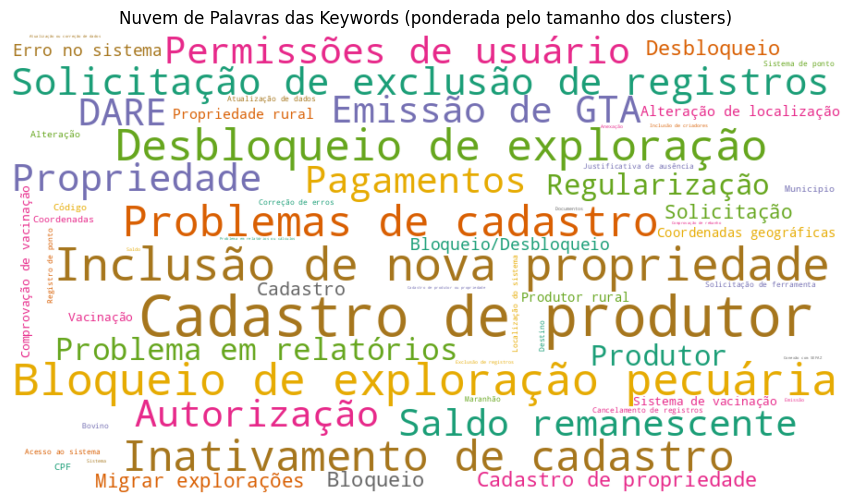

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# separar keywords
keywords_expanded = (
    clusters_df[["Keywords", "Size"]]
    .dropna()
    .assign(Keywords=lambda x: x["Keywords"].str.split(";"))
    .explode("Keywords")
)

keywords_expanded["Keywords"] = keywords_expanded["Keywords"].str.strip()
# calcular peso ponderado
keyword_weight = (
    keywords_expanded
    .groupby("Keywords")["Size"]
    .sum()
    .sort_values(ascending=False)
)

freq_dict = keyword_weight.to_dict()

colormap="Dark2"

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    colormap="Dark2"
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras das Keywords (ponderada pelo tamanho dos clusters)")
plt.show()

Tempo médio de resolução: 1293.38 horas
Tempo mediano de resolução: 1017.07 horas

Chamado com maior tempo de resolução:
id                                                                 609
id_classificacao                                                     3
id_lotacao                                                        87.0
ds_problema          Boa tarde, estamos tentando inserir a comprova...
dt_chamado                                     2021-10-20 16:28:45.000
id_situacao                                                          3
dt_fechamento                                      2022-06-26 23:14:45
dt_adocao                                          2021-10-21 08:07:32
Cluster ID                                                           6
tempo_resolucao_h                                          5967.120278
Name: 561, dtype: object


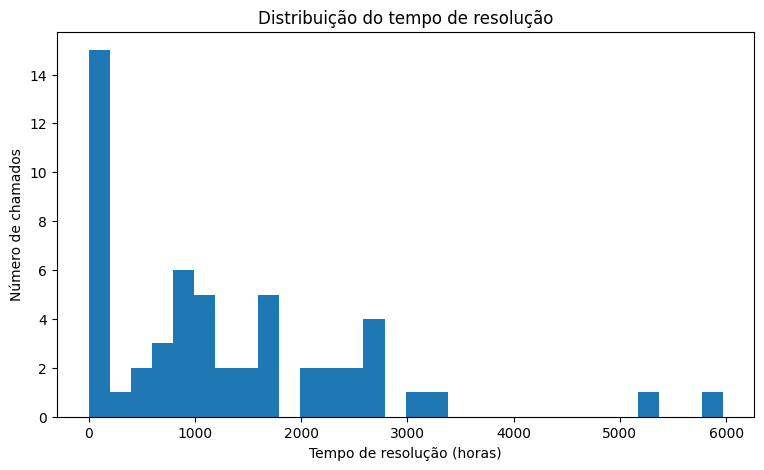

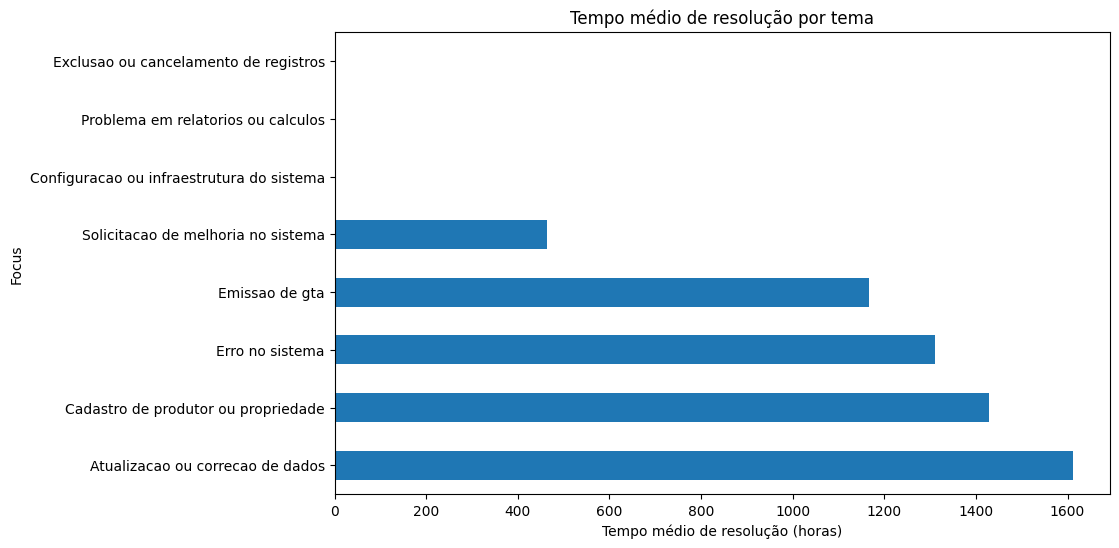

In [52]:
import matplotlib.pyplot as plt

articles_file = Path(clusters_path) / "chamado_abrir_202603041306_limpo_clustered.csv"

news_df = pd.read_csv(articles_file)

df = news_df

clusters_df = pd.read_csv(open_tickets_file)

df["dt_adocao"] = pd.to_datetime(df["dt_adocao"], errors="coerce")
df["dt_fechamento"] = pd.to_datetime(df["dt_fechamento"], errors="coerce")

# calcular tempo de resolução (adoção → fechamento)
df["tempo_resolucao_h"] = (
    df["dt_fechamento"] - df["dt_adocao"]
).dt.total_seconds() / 3600

# remover valores inválidos
df = df[df["tempo_resolucao_h"] > 0]

# métricas principais
media = df["tempo_resolucao_h"].mean()
mediana = df["tempo_resolucao_h"].median()

print(f"Tempo médio de resolução: {media:.2f} horas")
print(f"Tempo mediano de resolução: {mediana:.2f} horas")

idx_max = df["tempo_resolucao_h"].idxmax()
chamado_mais_demorado = df.loc[idx_max]

print("\nChamado com maior tempo de resolução:")
print(chamado_mais_demorado)

plt.figure(figsize=(9,5))

plt.hist(df["tempo_resolucao_h"], bins=30)

plt.xlabel("Tempo de resolução (horas)")
plt.ylabel("Número de chamados")
plt.title("Distribuição do tempo de resolução")

plt.show()

focus_map = {
    "Alteracao ou correcao de dados": "Atualizacao ou correcao de dados"
}

cluster_df = df.merge(clusters_df[["Cluster ID", "Focus"]], on="Cluster ID", how="left")

focus_expanded = (
    cluster_df[["Focus", "tempo_resolucao_h"]]
    .dropna()
    .assign(Focus=lambda x: x["Focus"].str.split("|"))
    .explode("Focus")
)

focus_expanded["Focus"] = (
    focus_expanded["Focus"]
    .str.strip()
    .apply(normalize_text)
    .replace(focus_map)
)

tempo_por_tema = (
    focus_expanded
    .groupby("Focus")["tempo_resolucao_h"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

tempo_por_tema.plot(kind="barh", figsize=(10,6))

plt.xlabel("Tempo médio de resolução (horas)")
plt.title("Tempo médio de resolução por tema")

plt.show()